In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)

In [4]:
#load processed data

df = pd.read_csv(
    "../data/processed/processed_walmart_sales.csv"
)

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)
df.head()

(382955, 47)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Quarter,WeekOfYear,DayOfWeek,DayOfMonth,Month_Sin,Month_Cos,Week_Sin,Week_Cos,Sales_Lag_1,Sales_Lag_2,Sales_Lag_4,Sales_Lag_8,Sales_Lag_12,Rolling_Mean,Rolling_Mean_4,Rolling_Mean_8,Rolling_Std_4,Historical_Avg_Sales,Has_Markdown,Total_Markdown,Type_A,Type_B,Type_C,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Store_Size_Category_Small,Store_Size_Category_Medium,Store_Size_Category_Large
0,1,1,2010-04-30,16555.11,0,151315,67.41,2.780,0.0,0.0,0.0,0.0,0.0,210.389546,7.808,2010,4,2,17,4,30,0.866025,-0.500000,0.885456,-0.464723,16145.35,17596.96,57258.43,21827.90,24924.50,23314.5825,33490.4125,28149.84875,20067.070906,29763.489167,0,0.0,1,0,0,0,1,0,0,0,1,0
1,1,1,2010-05-07,17413.94,0,151315,72.55,2.835,0.0,0.0,0.0,0.0,0.0,210.339968,7.808,2010,5,2,18,4,7,0.500000,-0.866025,0.822984,-0.568065,16555.11,16145.35,42960.91,21043.39,46039.49,16927.8400,23314.5825,27490.75000,13111.798178,28747.460000,0,0.0,1,0,0,0,1,0,0,0,1,0
2,1,1,2010-05-14,18926.74,0,151315,74.78,2.854,0.0,0.0,0.0,0.0,0.0,210.337426,7.808,2010,5,2,19,4,14,0.500000,-0.866025,0.748511,-0.663123,17413.94,16555.11,17596.96,22136.64,41595.55,17260.2850,16927.8400,27037.06875,691.672619,27937.922857,0,0.0,1,0,0,0,1,0,0,0,1,0
3,1,1,2010-05-21,14773.04,0,151315,76.44,2.826,0.0,0.0,0.0,0.0,0.0,210.617093,7.808,2010,5,2,20,4,21,0.500000,-0.866025,0.663123,-0.748511,18926.74,17413.94,16145.35,26229.21,19403.54,16917.2075,17260.2850,26635.83125,1230.316214,27337.177333,0,0.0,1,0,0,0,1,0,0,0,1,0
4,1,1,2010-05-28,15580.43,0,151315,80.44,2.759,0.0,0.0,0.0,0.0,0.0,210.896761,7.808,2010,5,2,21,4,28,0.500000,-0.866025,0.568065,-0.822984,14773.04,18926.74,16555.11,57258.43,21827.90,16673.5375,16917.2075,25203.81000,1733.352524,26551.918750,0,0.0,1,0,0,0,1,0,0,0,1,0


In [5]:
#check data range

print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

Start date: 2010-04-30 00:00:00
End date: 2012-10-26 00:00:00


In [6]:
#load saved model and feature list

model = joblib.load("../models/xgb_model.pkl")
features = joblib.load("../models/features.pkl")

In [7]:
print("Number of model features:", len(features))
print(features)

Number of model features: 45
Index(['Store', 'Dept', 'IsHoliday', 'Size', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Year', 'Month', 'Quarter', 'WeekOfYear', 'DayOfWeek',
       'DayOfMonth', 'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos',
       'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_4', 'Sales_Lag_8',
       'Sales_Lag_12', 'Rolling_Mean', 'Rolling_Mean_4', 'Rolling_Mean_8',
       'Rolling_Std_4', 'Historical_Avg_Sales', 'Has_Markdown',
       'Total_Markdown', 'Type_A', 'Type_B', 'Type_C', 'Season_Autumn',
       'Season_Spring', 'Season_Summer', 'Season_Winter',
       'Store_Size_Category_Small', 'Store_Size_Category_Medium',
       'Store_Size_Category_Large'],
      dtype='str')


In [8]:
#create unseen test period data

test = df[df["Date"] >= "2012-01-01"].copy()

print("Test shape:", test.shape)
print("Test date range:", test["Date"].min(), "to", test["Date"].max())

Test shape: (126921, 47)
Test date range: 2012-01-06 00:00:00 to 2012-10-26 00:00:00


In [9]:
X_test = test[features]
y_test = test["Weekly_Sales"]

In [10]:
print(list(X_test.columns) == list(features))

True


In [11]:
#generate demad predictions 

test["Predicted_Demand"] = model.predict(X_test)

In [12]:
test["Predicted_Demand"] = test["Predicted_Demand"].clip(lower=0)

In [13]:
test[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "Predicted_Demand"
    ]
].head(10)

,Store,Dept,Date,Weekly_Sales,Predicted_Demand
88,1,1,2012-01-06,16567.69,20490.162109
89,1,1,2012-01-13,16894.40,16423.746094
90,1,1,2012-01-20,18365.10,17868.105469
91,1,1,2012-01-27,18378.16,18029.431641
92,1,1,2012-02-03,23510.49,22986.435547
93,1,1,2012-02-10,36988.49,36323.898438
94,1,1,2012-02-17,54060.10,49530.226562
95,1,1,2012-02-24,20124.22,22107.736328
96,1,1,2012-03-02,20113.03,16520.638672
97,1,1,2012-03-09,21140.07,22424.919922


In [14]:
#evaluate the saved model again

def calculate_mape(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    valid = actual > 0

    return np.mean(
        np.abs(
            (actual[valid] - predicted[valid]) / actual[valid]
        )
    ) * 100

In [15]:
#calculate metrics

mae = mean_absolute_error(
    y_test,
    test["Predicted_Demand"]
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test["Predicted_Demand"]
    )
)

r2 = r2_score(
    y_test,
    test["Predicted_Demand"]
)

mape = calculate_mape(
    y_test,
    test["Predicted_Demand"]
)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")
print("R² Score:", round(r2, 4))

MAE: 736.48
RMSE: 1730.2
MAPE: 788.09 %
R² Score: 0.9939


In [16]:
#inventory input values 

np.random.seed(42)

test["Current_Stock"] = (
    test["Predicted_Demand"] *
    np.random.uniform(0.6, 1.5, len(test))
).round()

In [17]:
#inventory recommendation logic

def inventory_recommendation(
    predicted_demand,
    current_stock,
    safety_stock_percentage=0.20
):
    predicted_demand = max(float(predicted_demand), 0)
    current_stock = max(float(current_stock), 0)

    safety_stock = (
        predicted_demand *
        safety_stock_percentage
    )

    recommended_stock = (
        predicted_demand +
        safety_stock
    )

    reorder_quantity = max(
        recommended_stock - current_stock,
        0
    )

    return pd.Series({
        "Safety_Stock": round(safety_stock, 2),
        "Recommended_Stock": round(recommended_stock, 2),
        "Reorder_Quantity": round(reorder_quantity, 2)
    })

In [19]:
inventory_results = test.apply(
    lambda row: inventory_recommendation(
        predicted_demand=row["Predicted_Demand"],
        current_stock=row["Current_Stock"]
    ),
    axis=1
)

test = pd.concat(
    [test, inventory_results],
    axis=1
)

In [20]:
test[
    [
        "Predicted_Demand",
        "Current_Stock",
        "Safety_Stock",
        "Recommended_Stock",
        "Reorder_Quantity"
    ]
].head()

,Predicted_Demand,Current_Stock,Safety_Stock,Recommended_Stock,Reorder_Quantity
88,20490.162109,19201.0,4098.03,24588.19,5387.19
89,16423.746094,23907.0,3284.75,19708.50,0.00
90,17868.105469,22492.0,3573.62,21441.73,0.00
91,18029.431641,20532.0,3605.89,21635.32,1103.32
92,22986.435547,17020.0,4597.29,27583.72,10563.72


In [21]:
#create stock risk categories

def classify_stock_status(
    current_stock,
    predicted_demand,
    recommended_stock
):
    if current_stock < predicted_demand:
        return "High Risk"

    elif current_stock < recommended_stock:
        return "Medium Risk"

    elif current_stock > recommended_stock * 1.5:
        return "Overstock Risk"

    else:
        return "Healthy"

In [22]:
test["Stock_Status"] = test.apply(
    lambda row: classify_stock_status(
        current_stock=row["Current_Stock"],
        predicted_demand=row["Predicted_Demand"],
        recommended_stock=row["Recommended_Stock"]
    ),
    axis=1
)

In [23]:
test["Stock_Status"].value_counts()

Stock_Status
High Risk         56186
Healthy           42525
Medium Risk       28209
Overstock Risk        1
Name: count, dtype: int64

In [24]:
#reorder flag

test["Reorder_Required"] = (
    test["Reorder_Quantity"] > 0
).astype(int)

In [25]:
test["Reorder_Message"] = np.where(
    test["Reorder_Required"] == 1,
    "Reorder Required",
    "Stock Sufficient"
)

In [26]:
#calculate prediction error

test["Prediction_Error"] = (
    test["Weekly_Sales"] -
    test["Predicted_Demand"]
)

test["Absolute_Error"] = (
    test["Prediction_Error"].abs()
)

In [27]:
test["Percentage_Error"] = np.where(
    test["Weekly_Sales"] > 0,
    (
        test["Absolute_Error"] /
        test["Weekly_Sales"]
    ) * 100,
    np.nan
)

In [28]:
#create business KPIs

total_predicted_demand = test["Predicted_Demand"].sum()

average_predicted_demand = test["Predicted_Demand"].mean()

total_reorder_quantity = test["Reorder_Quantity"].sum()

products_requiring_reorder = test["Reorder_Required"].sum()

high_risk_records = (
    test["Stock_Status"] == "High Risk"
).sum()

healthy_records = (
    test["Stock_Status"] == "Healthy"
).sum()

In [29]:
#print KPIs

print(
    "Total predicted demand:",
    round(total_predicted_demand, 2)
)

print(
    "Average predicted demand:",
    round(average_predicted_demand, 2)
)

print(
    "Total reorder quantity:",
    round(total_reorder_quantity, 2)
)

print(
    "Records requiring reorder:",
    products_requiring_reorder
)

print(
    "High-risk records:",
    high_risk_records
)

print(
    "Healthy records:",
    healthy_records
)

Total predicted demand: 2003772500.0
Average predicted demand: 15787.56
Total reorder quantity: 399924197.9
Records requiring reorder: 84395
High-risk records: 56186
Healthy records: 42525


In [30]:
#store level demand summary

store_summary = (
    test.groupby("Store")
    .agg(
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Demand=("Predicted_Demand", "sum"),
        Current_Stock=("Current_Stock", "sum"),
        Reorder_Quantity=("Reorder_Quantity", "sum")
    )
    .reset_index()
)

In [31]:
#calculate differences

store_summary["Forecast_Difference"] = (
    store_summary["Actual_Sales"] -
    store_summary["Predicted_Demand"]
)

In [32]:
#department level summary

department_summary = (
    test.groupby("Dept")
    .agg(
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Demand=("Predicted_Demand", "sum"),
        Reorder_Quantity=("Reorder_Quantity", "sum")
    )
    .reset_index()
)

In [33]:
#highest demand departments

department_summary.sort_values(
    "Predicted_Demand",
    ascending=False
).head(10)

,Dept,Actual_Sales,Predicted_Demand,Reorder_Quantity
70,92,1.516294e+08,152579120.0,31177731.28
73,95,1.378918e+08,138362960.0,28551262.13
36,38,1.210016e+08,120675184.0,23194306.33
68,90,8.971536e+07,90235784.0,17954385.24
37,40,8.919934e+07,88988840.0,17363756.35
1,2,8.505299e+07,85324240.0,17049553.59
58,72,8.030791e+07,81579336.0,16208625.69
69,91,6.648817e+07,66300404.0,12657278.33
12,13,5.951081e+07,59332152.0,12131083.89
7,8,5.887608e+07,58759808.0,10861383.65


In [34]:
#monthly demand summary

monthly_summary = (
    test.groupby(
        test["Date"].dt.to_period("M")
    )
    .agg(
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Demand=("Predicted_Demand", "sum")
    )
    .reset_index()
)

monthly_summary["Date"] = (
    monthly_summary["Date"]
    .dt.to_timestamp()
)

In [35]:
monthly_summary.head()

,Date,Actual_Sales,Predicted_Demand
0,2012-01-01,1.688900e+08,173412160.0
1,2012-02-01,1.920560e+08,190802672.0
2,2012-03-01,2.315036e+08,229728448.0
3,2012-04-01,1.889193e+08,190182320.0
4,2012-05-01,1.887641e+08,188260688.0


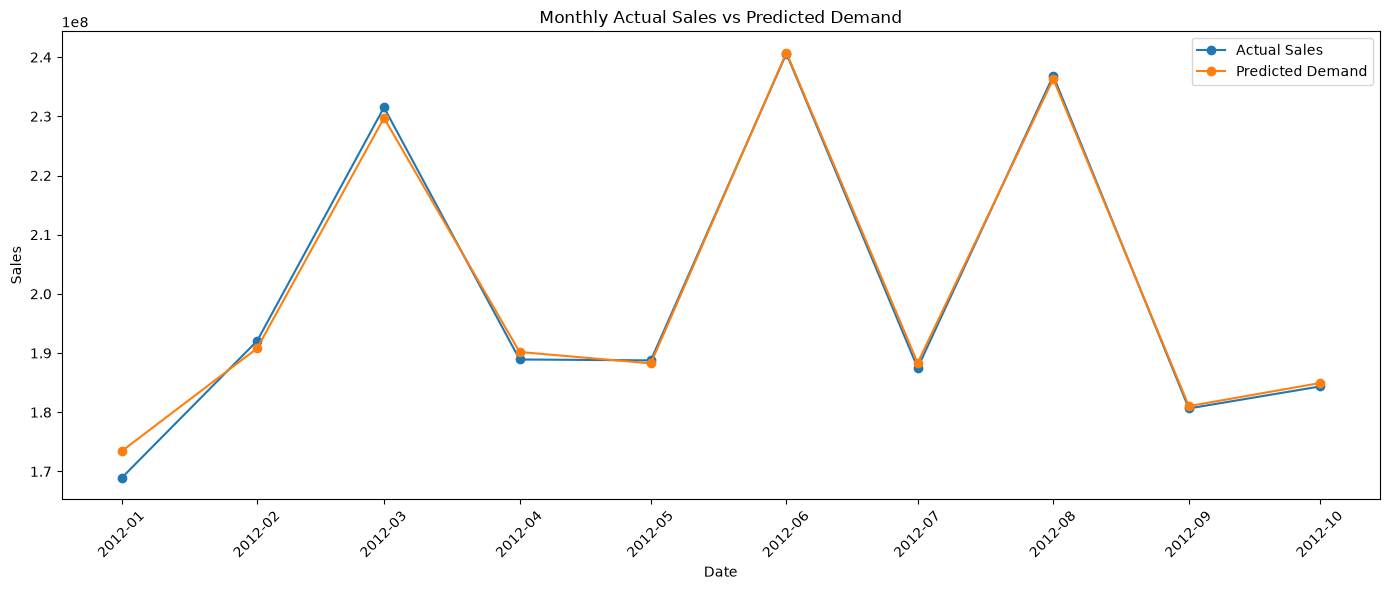

In [36]:
#actual vs predicted monthly demand

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_summary["Date"],
    monthly_summary["Actual_Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_summary["Date"],
    monthly_summary["Predicted_Demand"],
    marker="o",
    label="Predicted Demand"
)

plt.title("Monthly Actual Sales vs Predicted Demand")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

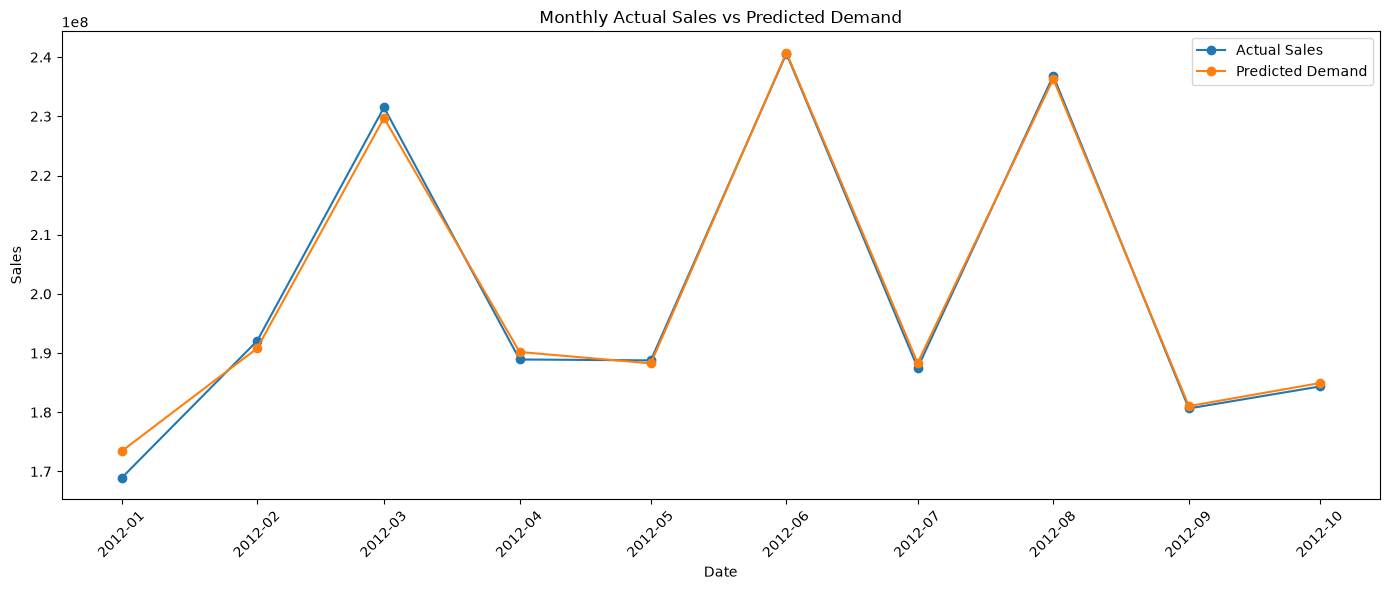

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_summary["Date"],
    monthly_summary["Actual_Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_summary["Date"],
    monthly_summary["Predicted_Demand"],
    marker="o",
    label="Predicted Demand"
)

plt.title("Monthly Actual Sales vs Predicted Demand")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../images/monthly_actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

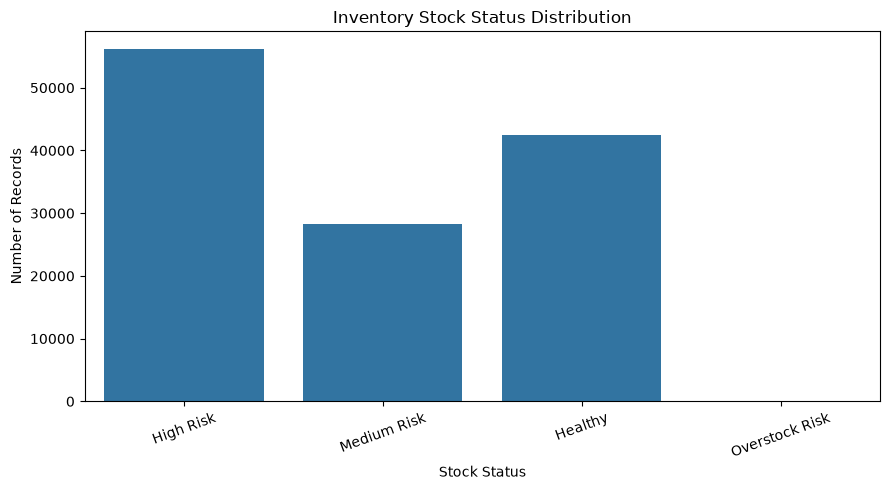

In [38]:
#plot stock status distribution

plt.figure(figsize=(9, 5))

sns.countplot(
    data=test,
    x="Stock_Status",
    order=[
        "High Risk",
        "Medium Risk",
        "Healthy",
        "Overstock Risk"
    ]
)

plt.title("Inventory Stock Status Distribution")
plt.xlabel("Stock Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

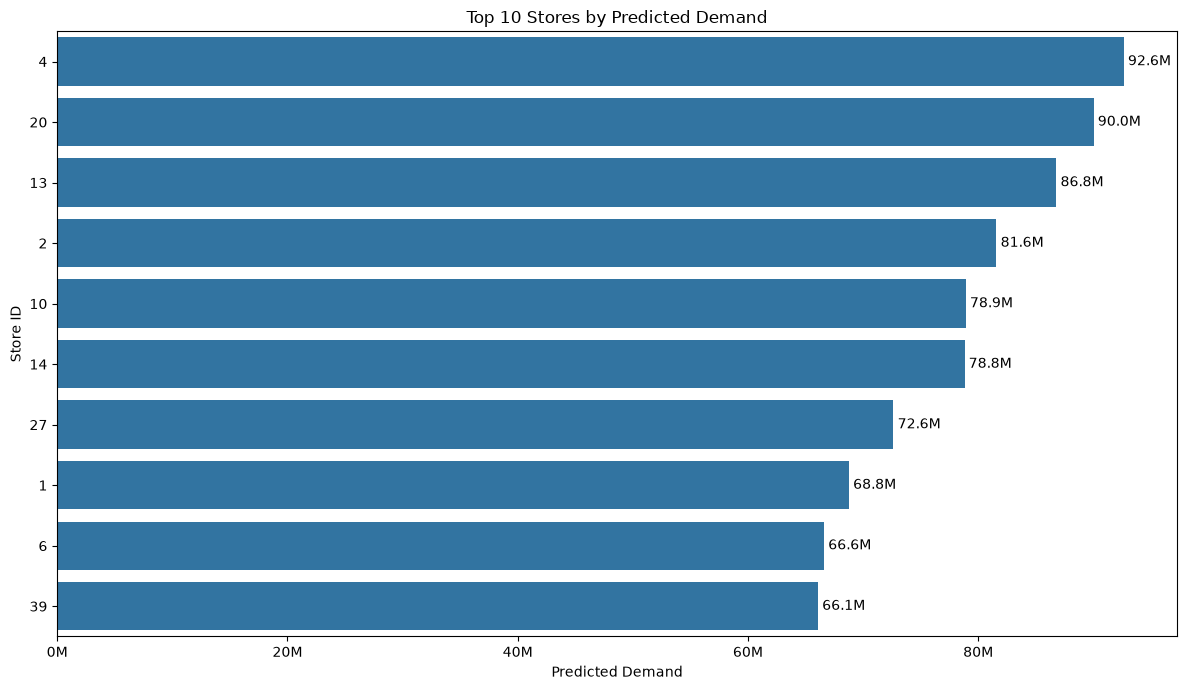

In [39]:
#plot top stores by predicted demand

top_stores = (
    store_summary
    .sort_values("Predicted_Demand", ascending=False)
    .head(10)
    .copy()
)

# Convert Store IDs into categorical labels
top_stores["Store"] = top_stores["Store"].astype(str)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_stores,
    x="Predicted_Demand",
    y="Store",
    errorbar=None
)

plt.title("Top 10 Stores by Predicted Demand")
plt.xlabel("Predicted Demand")
plt.ylabel("Store ID")

# Display values in millions
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"{value / 1_000_000:.0f}M")
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value / 1_000_000:.1f}M"
            for value in top_stores["Predicted_Demand"]
        ],
        padding=3
    )

plt.tight_layout()
plt.show()

In [40]:
#top depatments requiring reorder

top_reorder_departments = (
    department_summary
    .sort_values(
        "Reorder_Quantity",
        ascending=False
    )
    .head(10)
)

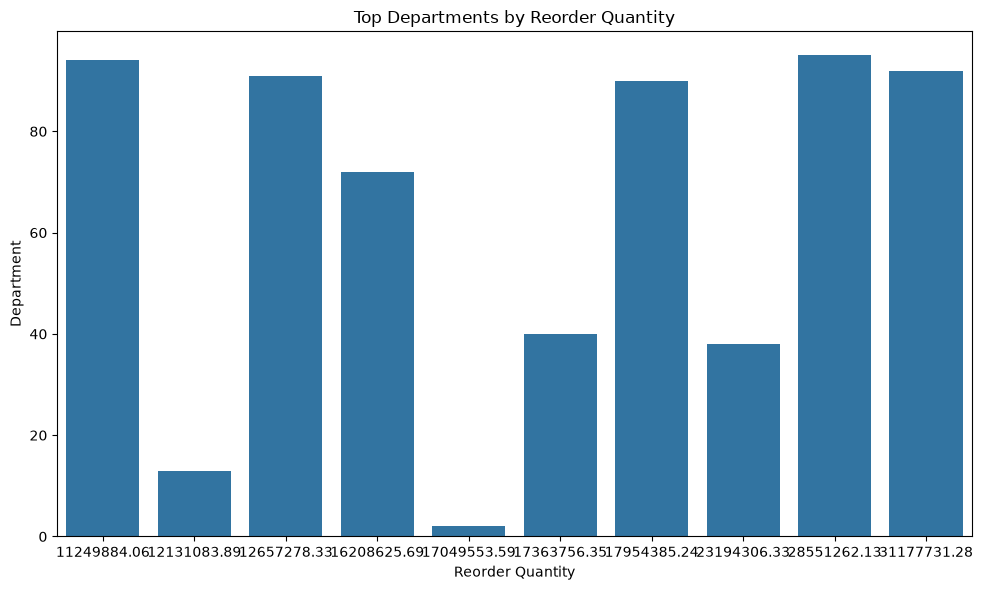

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_reorder_departments,
    x="Reorder_Quantity",
    y="Dept"
)

plt.title("Top Departments by Reorder Quantity")
plt.xlabel("Reorder Quantity")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

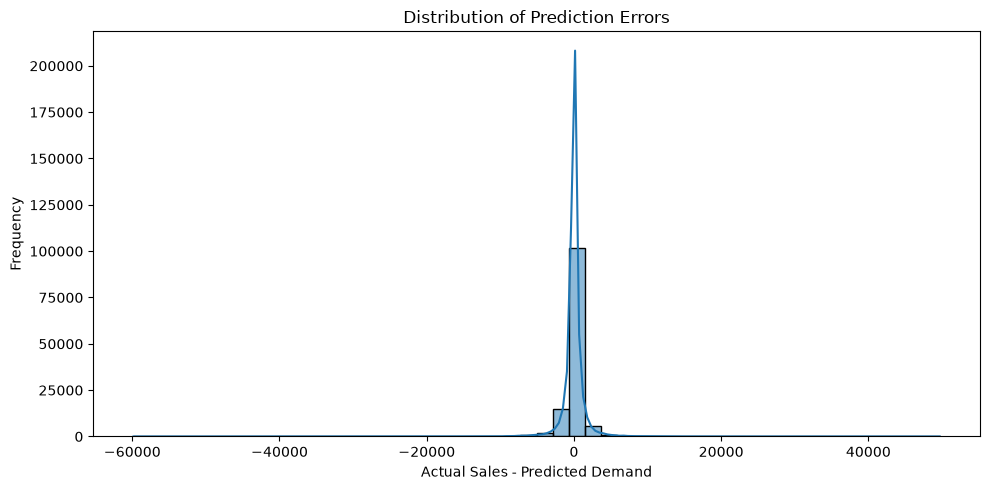

In [42]:
#plot residual distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    test["Prediction_Error"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Actual Sales - Predicted Demand")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [43]:
#largest prediction errors

largest_errors = test[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "Predicted_Demand",
        "Absolute_Error",
        "IsHoliday"
    ]
].sort_values(
    "Absolute_Error",
    ascending=False
).head(20)

largest_errors

,Store,Dept,Date,Weekly_Sales,Predicted_Demand,Absolute_Error,IsHoliday
242031,27,92,2012-01-27,118083.31,177919.859375,59836.549375,0
123531,14,72,2012-01-06,65662.57,121840.101562,56177.531562,0
125014,14,92,2012-10-26,164464.02,215919.125000,51455.105000,0
251239,28,92,2012-01-06,157085.08,107396.101562,49688.978437,0
125012,14,92,2012-10-12,156174.21,204438.296875,48264.086875,0
242034,27,92,2012-02-17,138805.54,186042.328125,47236.788125,0
27740,4,7,2012-01-06,34402.78,81629.171875,47226.391875,0
124999,14,92,2012-07-13,137087.77,184074.390625,46986.620625,0
124996,14,92,2012-06-22,134236.16,180849.875000,46613.715000,0
86848,10,72,2012-04-27,95980.33,137959.359375,41979.029375,0


In [44]:
#SHAP

import numpy as np
import numba
import shap

print("NumPy:", np.__version__)
print("Numba:", numba.__version__)
print("SHAP:", shap.__version__)

NumPy: 2.2.6
Numba: 0.66.0
SHAP: 0.52.0


In [45]:
shap_sample = X_test.sample(
    n=min(2000, len(X_test)),
    random_state=42
)

In [47]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    shap_sample,
    check_additivity=False
)

C:\Users\sanik\AppData\Local\Temp\ipykernel_29740\739425910.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


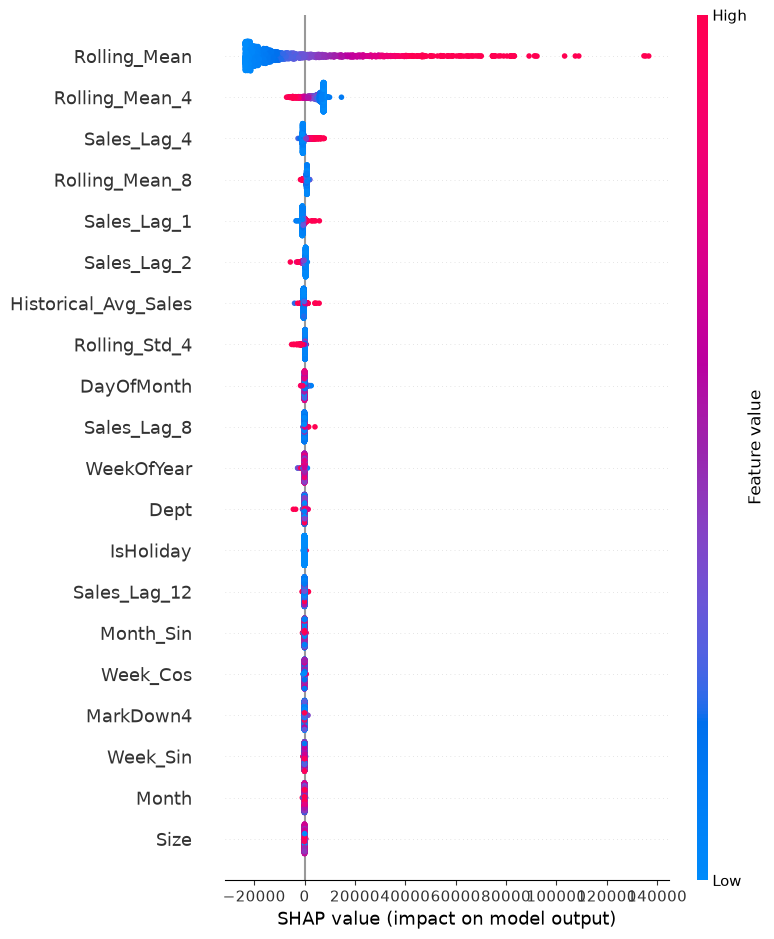

In [48]:
#global summary plot

shap.summary_plot(
    shap_values,
    shap_sample
)

C:\Users\sanik\AppData\Local\Temp\ipykernel_29740\2664442415.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


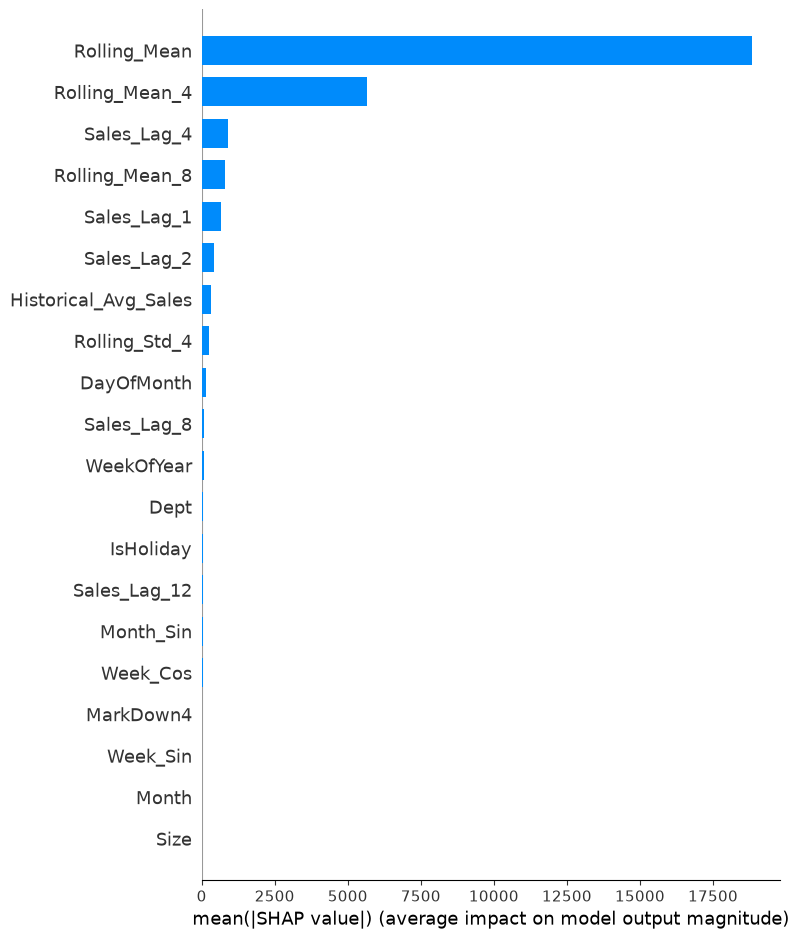

In [49]:
#create SHAP plot

shap.summary_plot(
    shap_values,
    shap_sample,
    plot_type="bar"
)

In [50]:
#explain one individuall prediction

single_record = X_test.iloc[[0]]

In [51]:
#its shap values

single_shap_values = explainer.shap_values(
    single_record
)

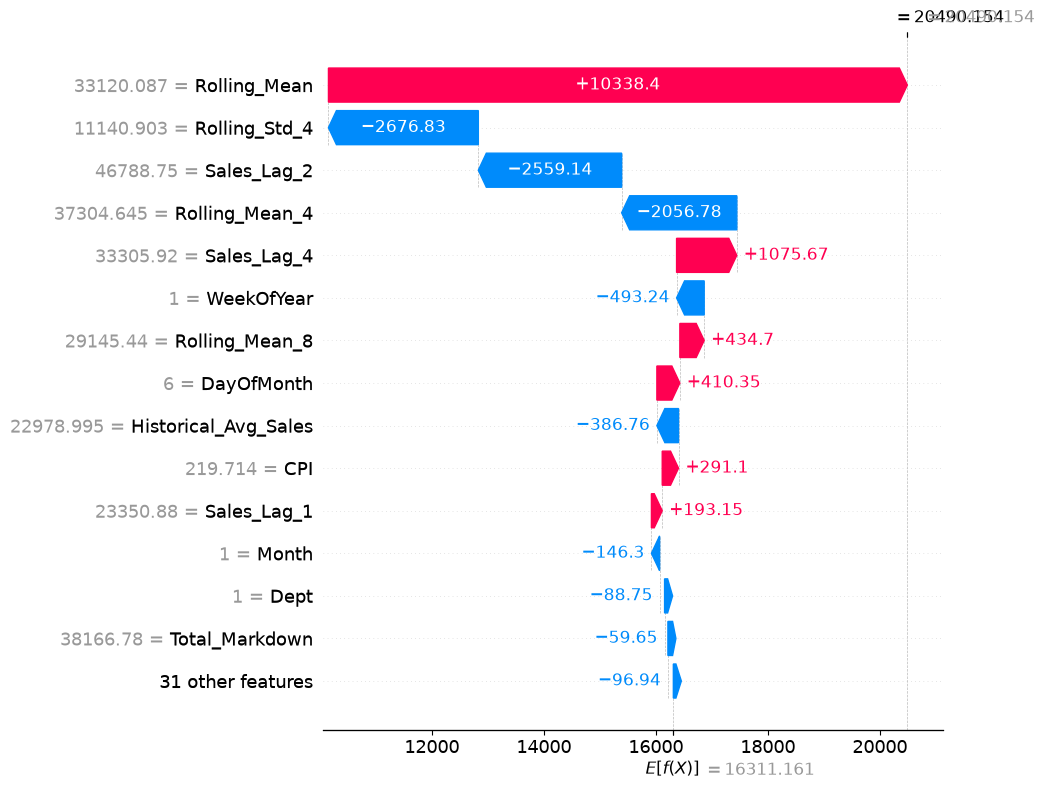

In [52]:
shap_explanation = shap.Explanation(
    values=single_shap_values[0],
    base_values=explainer.expected_value,
    data=single_record.iloc[0],
    feature_names=single_record.columns
)

shap.plots.waterfall(
    shap_explanation,
    max_display=15
)

In [53]:
#create reusable prediction function

def predict_demand(input_data):
    input_df = pd.DataFrame([input_data])

    missing_features = [
        feature
        for feature in features
        if feature not in input_df.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing features: {missing_features}"
        )

    input_df = input_df[features]

    prediction = model.predict(input_df)[0]

    return max(float(prediction), 0)

In [54]:
#test using existing row

sample_input = X_test.iloc[0].to_dict()

sample_prediction = predict_demand(
    sample_input
)

print("Predicted demand:", sample_prediction)

Predicted demand: 20490.162109375


In [55]:
#create one complete business response function

def generate_business_prediction(
    input_data,
    current_stock,
    safety_stock_percentage=0.20
):
    predicted_demand = predict_demand(
        input_data
    )

    inventory = inventory_recommendation(
        predicted_demand=predicted_demand,
        current_stock=current_stock,
        safety_stock_percentage=safety_stock_percentage
    )

    stock_status = classify_stock_status(
        current_stock=current_stock,
        predicted_demand=predicted_demand,
        recommended_stock=inventory["Recommended_Stock"]
    )

    return {
        "predicted_demand": round(
            predicted_demand,
            2
        ),
        "current_stock": round(
            float(current_stock),
            2
        ),
        "safety_stock": inventory[
            "Safety_Stock"
        ],
        "recommended_stock": inventory[
            "Recommended_Stock"
        ],
        "reorder_quantity": inventory[
            "Reorder_Quantity"
        ],
        "stock_status": stock_status
    }

In [56]:
business_result = generate_business_prediction(
    input_data=sample_input,
    current_stock=10000
)

business_result

{'predicted_demand': 20490.16,
 'current_stock': 10000.0,
 'safety_stock': np.float64(4098.03),
 'recommended_stock': np.float64(24588.19),
 'reorder_quantity': np.float64(14588.19),
 'stock_status': 'High Risk'}

In [57]:
{
    "predicted_demand": 12500.50,
    "current_stock": 10000.00,
    "safety_stock": 2500.10,
    "recommended_stock": 15000.60,
    "reorder_quantity": 5000.60,
    "stock_status": "High Risk"
}

{'predicted_demand': 12500.5,
 'current_stock': 10000.0,
 'safety_stock': 2500.1,
 'recommended_stock': 15000.6,
 'reorder_quantity': 5000.6,
 'stock_status': 'High Risk'}

In [61]:
#save the complete pipeline

prediction_pipeline = {
    "model": model,
    "features": list(features),
    "safety_stock_percentage": 0.20
}

In [64]:
joblib.dump(
    prediction_pipeline,
    "../models/demand_prediction_pipeline.pkl"
)

['../models/demand_prediction_pipeline.pkl']

In [65]:
loaded_pipeline = joblib.load(
    "../models/demand_prediction_pipeline.pkl"
)

print(loaded_pipeline.keys())

dict_keys(['model', 'features', 'safety_stock_percentage'])


In [67]:
#save detailed predictions

output_columns = [
    "Store",
    "Dept",
    "Date",
    "Weekly_Sales",
    "Predicted_Demand",
    "Prediction_Error",
    "Absolute_Error",
    "Current_Stock",
    "Safety_Stock",
    "Recommended_Stock",
    "Reorder_Quantity",
    "Stock_Status",
    "Reorder_Required",
    "Reorder_Message"
]

In [69]:
test[output_columns].to_csv(
    "../forecasts/demand_predictions.csv",
    index=False
)

In [70]:
store_summary.to_csv(
    "../forecasts/store_summary.csv",
    index=False
)

department_summary.to_csv(
    "../forecasts/department_summary.csv",
    index=False
)

monthly_summary.to_csv(
    "../forecasts/monthly_summary.csv",
    index=False
)

In [71]:
#save model metrics

metrics_df = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ],
    "Value": [
        mae,
        rmse,
        mape,
        r2
    ]
})

In [72]:
metrics_df.to_csv(
    "../models/final_model_metrics.csv",
    index=False
)

metrics_df

,Metric,Value
0,MAE,736.479601
1,RMSE,1730.198850
2,MAPE,788.086757
3,R2,0.993894


In [73]:
## Day 4 Observations

# 1. The saved XGBoost model was used to predict demand on the unseen test period.
# 2. Negative model predictions were clipped to zero because product demand cannot be negative.
# 3. Inventory recommendations were calculated using predicted demand, current stock and a 20% safety-stock level.
# 4. Products were classified into High Risk, Medium Risk, Healthy and Overstock Risk categories.
# 5. Store-level, department-level and monthly demand summaries were generated for the dashboard.
# 6. SHAP was used to identify the features that contributed most to demand predictions.
# 7. A reusable prediction pipeline and business-response function were prepared for FastAPI integration.